# Árvore de decisão

## Autores

| Nome | nUSP |
| :--- | :--- |
| Débora da Silva Morais | 15615790 |
| Guilherme de Abreu Barreto | 12543033 |

## Introdução

Este notebook trata-se de uma continuidade ao exercício apresentado na semana anterior. Após explorarmos as propriedades dos datasets descritos no artigo de  Zanfei et al., [Novel approach for burst detection in water distribution systems based on graph neural networks](https://www.sciencedirect.com/science/article/abs/pii/S2210670722004073) partimos para uma tentativa para classificação da presença ou não de vazamentos no sistema com o uso da técnica [_Árvore de Decisão_](https://scikit-learn.org/stable/modules/tree.html). A seguir, explicamos as etapas para execução desta análise.

## Carregamento de dependências

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    auc,
)

## Constantes

A seguir são definidos os seguintes atributos:

- `SEED`: valor inteiro utilizado para cálculo de números pseudo-aleatórios. Assegura a reprodutibilidade do notebook em procedimentos probabilísticos como a geração pseudo-aleatória de divisões de treino e validação.

- `DATASETS_FOLDER` e `DATASETS`: Referem-se ao diretório e arquivos onde os dados de referência para este estudo estão localizados.

In [2]:
SEED = 42
DATASETS_FOLDER = '../generated-datasets-for-burst-detection-in-water-distribution-systems'
DATASETS = [f'{DATASETS_FOLDER}/WDts{i}/WDts{i}_dataset.csv' for i in range(1, 5)]

## Carregamento dos dados

A função abaixo carrega os dados a partir dos arquivos de referência, eliminando quaisquer registros em que a variável alvo não esteja presente e atribuindo um valor médio a quaisquer valores faltantes observados nos parâmetros.

In [3]:
def load_data(
    csv_path: str, features: list[str], target: str
) -> tuple[pd.DataFrame, ...]:
    df = pd.read_csv(
        csv_path,
        dtype={target: bool},
        index_col=False,
        sep=';',
    )
    df = df[df[target].notna()]
    df.info()
    return df[features].fillna(df[features].mean()), df[target]

## Dividir conjuntos de treino e teste

Abaixo dividimos o conjunto de registros utilizados para o treino (4/5 do total) do modelo e seu posterior teste (1/5 restante). 

In [4]:
def split_train_test(
    X: pd.DataFrame, y: pd.DataFrame
) -> tuple[pd.DataFrame, ...]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )

    print(f"Tamanho do conjunto de treino: {X_train.shape}")
    print(f"Tamanho do conjunto de teste: {X_test.shape}")
    return X_train, X_test, y_train, y_test

## Criar o modelo classificador e encontrar os hiperparâmetros ótimos para este

Conforme exemplificado na última aula por Rubens, et al., utilizamos o procedimento de GridSearch com 5-fold cross-validation no conjunto de treino para buscar a combinação ótima de hiperparâmetros do modelo. São testados diferentes valores para os seguintes parâmetros:

- `critetion`: O índice de inequidade utilizado para a estipular um dado parâmetro é ou não um bom critério no atual nó da árvore de decisão. São avaliados o índice de Gini, a enropia de Shannon, e a função de perda de entropia cruzada (_log loss_).
- `max_depth`: A profundidade máxima da árvore. Esta descreve um número máximo de decisões a serem tomadas antes de se chegar a um resultado (um nó folha).
- `min_samples_split`: O número mínimo de amostras que deve restar em cada nó após uma divisão na árvore de decisão.
- `min_samples_leaf`: O número mínimo de amostras em cada folha (resposta) da árvore.

A qualidade do modelo é aferida pela sua pontuação $\text{F1}$, expressa pela fórmula:

$$
\text{F1} = \dfrac{2 \cdot \text{VP}}{2 \cdot \text{VP} + \text{FP} + \text{FN}}
$$

Sendo:

- $\text{VP}$ o número absoluto de casos postivos corretamente avaliados como tal.
- $\text{FP}S o número absoluto de casos negativos avaliados como sendo positivos.
- $\text{FN}$ o número absoluto de casos positivos avaliados com osendo negativos.

Ou seja, a pontuação $\text{F1}$ pode ser interpretada como sendo a média armînica entre a [precisão e a revocação](https://pt.wikipedia.org/wiki/Precis%C3%A3o_e_revoca%C3%A7%C3%A3o). A escolha desta métrica se deve a natureza imbalanceada do conjunto de dados, atestada no execício anterior, onde os casos de não-vazamento compõem uma maioria significativa.

In [5]:
def tune_hyper_parameters(
    X_train: pd.DataFrame, y_train: pd.DataFrame
) -> tuple[GridSearchCV, DecisionTreeClassifier]:
    dt = DecisionTreeClassifier(random_state=SEED)
    param_grid = {
        'criterion': ["gini", "entropy", "log_loss"],
        'max_depth': range(1, 21),
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    gs = GridSearchCV(
        dt, param_grid, cv=5, scoring='f1', n_jobs=-1
    )
    gs.fit(X_train, y_train)
    best_dt = gs.best_estimator_
    return gs, best_dt.fit(X_train, y_train)

## Avaliar predição do modelo sobre o conjunto de teste

A seguir é feita a predição do modelo sobre o conjunto de teste (`y_pred = dt.predict(X_test)`) e avaliamos os resultados segundo os seguintes parâmetros:

1. **Matriz de confusão**: exibe-se o percentual de verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos na predição.

2. **Curva ROC**: Os autores Egan (1975) e Swets et al. (2000) descrevem um gráfico ROC como uma técnica para visualizar, organizar e selecionar classificadores baseado em seu desempenho. Esse método tem sido utilizado há muito tempo para avaliar o desempenho de um modelo de classificação binária ou de um teste diagnóstico, plotando a Taxa de Verdadeiros Positivos – TPR (sensibilidade) no eixo Y contra a Taxa de Falsos Positivos - FPR (especificidade) no eixo X, para todos os limiares de decisão possíveis.
	
    A curva é concebida ao calcular a TPR e a FPR para diferentes limiares de decisão. Quanto mais alta a curva (eixo Y) melhor, assim como quanto mais para a esquerda (eixo X). Ou seja, um teste com um bom desempenho estará mais próximo do canto superior esquerdo do gráfico (Fawcett, 2004).

3. **Árvore de decisão**: Exibe-se o diagrama da árvore de decisão resultante.

4. **Importância dos parâmetros**: gráfico de barras comparando a relativa importância dos parâmetros nas decisões na árvore.

5. **Sumário final**: o relatório dos hiperparâmetros que levam a produzir o melhor resultado de classificação e qual foi este resultado obtido.

---

Egan, J. P.: 1975, Signal Detection Theory and ROC Analysis, Series in Cognitition
and Perception. New York: Academic Press.

FAWCETT, Tom. ROC graphs: notes and practical considerations for researchers. Palo Alto: HP Laboratories, 2004. Kluwer Academic Publishers.

In [6]:
def evaluate_results(
    gs: GridSearchCV,
    dt: DecisionTreeClassifier,
    X_test: pd.DataFrame,
    y_test: pd.DataFrame,
    testset_name: str,
    features: list[str]
) -> None:
    y_pred = dt.predict(X_test)

    # Probabilities for class 1 (burst)
    y_pred_proba = dt.predict_proba(X_test)[:, 1]
    test_roc_auc = roc_auc_score(y_test, y_pred_proba)
    test_accuracy = accuracy_score(y_test, y_pred)

    print("\nRelatório de classificação:")
    print(classification_report(y_test, y_pred))

    # Print Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_percentage = cm.astype('float') /cm.sum(axis=1)[:, np.newaxis] * 100
    plt.figure(figsize=(8,6))
    labels = ["Falso", "Verdadeiro"]
# The corrected heatmap plotting code
    sns.heatmap(
        cm_percentage,
        annot=True,
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        fmt='.2f'
    )
    plt.xlabel('Previsão')
    plt.ylabel('Realidade')
    plt.title(f"Matrix de confusão, conjunto de teste {testset_name}")
    plt.show

    # Plot ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(10, 8))
    plt.plot(
        fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})'
    )
    plt.plot(
        [0, 1],
        [0, 1],
        color='navy',
        lw=2,
        linestyle='--',
        label='Classificador aleatório'
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de falsos positivos')
    plt.ylabel('Taxa de positivos verdadeiros')
    plt.title(f'Curva ROC, conjunto de teste {testset_name}')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Plot decision tree
    ax = plt.subplots(figsize=(12,12))[1]
    plot_tree(dt, feature_names=features, ax=ax)

    # Plot feature importance
    feature_importance = pd.DataFrame({
        'feature': features,
        'importance': dt.feature_importances_
    }).sort_values('importance', ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance, x='importance', y='feature')
    plt.title(
        f'Importância do parâmetro na árvore de decisão, conjunto de teste {testset_name}'
    )
    plt.tight_layout()
    plt.show()

    # Final model performance summary
    print("\n" + "=" * 60)
    print("SUMÀRIO FINAL DO MODELO")
    print("="*60)
    print(
        f"Melhor critério de separação: {gs.best_params_['criterion']}"
    )
    print(
        f"Melhor profundidade máxima: {gs.best_params_['max_depth']}"
    )
    print(
        f"Melhor número mínimo de amostras por divisão: {gs.best_params_['min_samples_split']}"
    )
    print(
        f"Melhor número mínimo de amostras por folha: {gs.best_params_['min_samples_leaf']}"
    )
    print(
        f"Melhor pontuação F1 na validação cruzada: {gs.best_score_:.4f}"
    )
    print(
        f"Pontuação ROC AUC no conjunto de teste: {test_roc_auc:.4f}"
    )
    print(
        f"Acurácia no conjunto de teste: {test_accuracy:.4f}"
    )
    print(
        f"Número de parâmetros: {len(features)}"
    )
    print(
        f"Parâmetro mais impactante: {feature_importance.iloc[0]['feature']} "
        f"(imporância: {feature_importance.iloc[0]['importance']:.4f})"
    )

## Resultados

In [7]:
def decision_tree_pipeline(csv_path:str) -> None:
    target = 'burst'
    features = [
        f'flow_meter{i}' for i in range(1, 5)
    ] + [
        f'{i}_press' for i in [3, 12, 36, 50, 60, 84, 93, 112, 138, 139]
    ]
    X, y = load_data(csv_path, features, target)
    X_train, X_test, y_train, y_test = split_train_test(X, y)
    grid_search, decision_tree = tune_hyper_parameters(X_train, y_train)
    evaluate_results(
        grid_search,
        decision_tree,
        X_test,
        y_test,
        csv_path.rsplit('/', 1)[-1],
        features
    )

### Conjunto WDts1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        35040 non-null  object 
 1   burst        35040 non-null  bool   
 2   flow_meter1  35040 non-null  float64
 3   flow_meter2  35040 non-null  float64
 4   flow_meter3  35040 non-null  float64
 5   flow_meter4  35040 non-null  float64
 6   3_press      35040 non-null  float64
 7   12_press     35040 non-null  float64
 8   36_press     35040 non-null  float64
 9   50_press     35040 non-null  float64
 10  60_press     35040 non-null  float64
 11  84_press     35040 non-null  float64
 12  93_press     35040 non-null  float64
 13  112_press    35040 non-null  float64
 14  138_press    35040 non-null  float64
 15  139_press    35040 non-null  float64
dtypes: bool(1), float64(14), object(1)
memory usage: 4.0+ MB
Tamanho do conjunto de treino: (28032, 14)
Tamanho do conjunto de teste: 

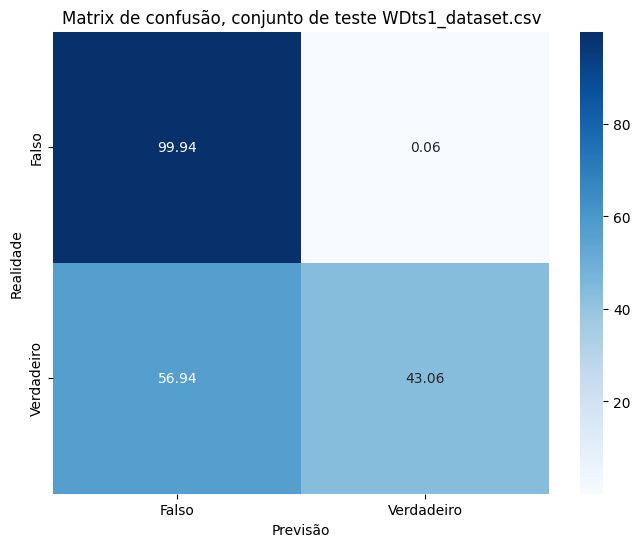

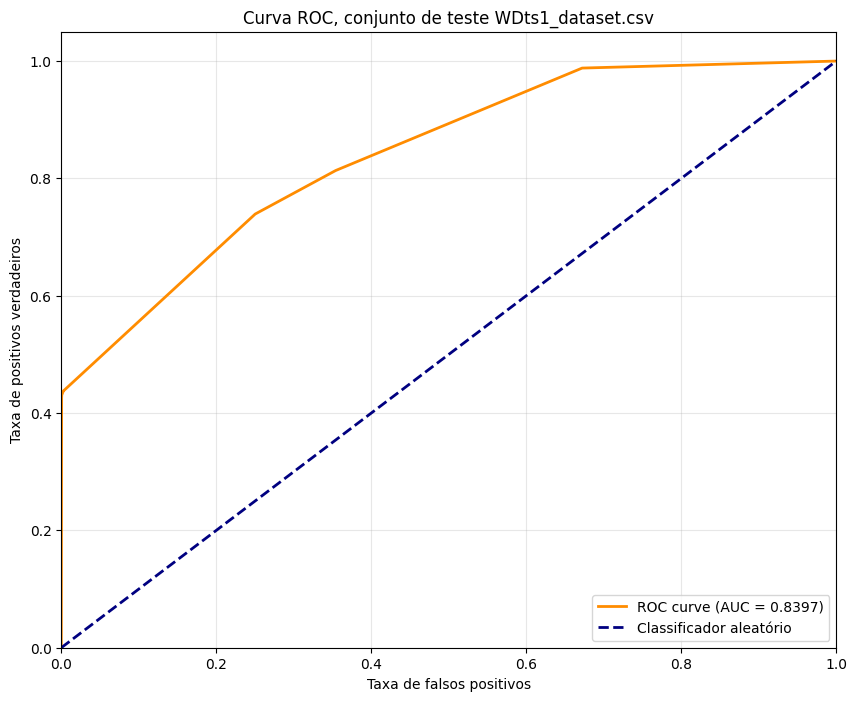

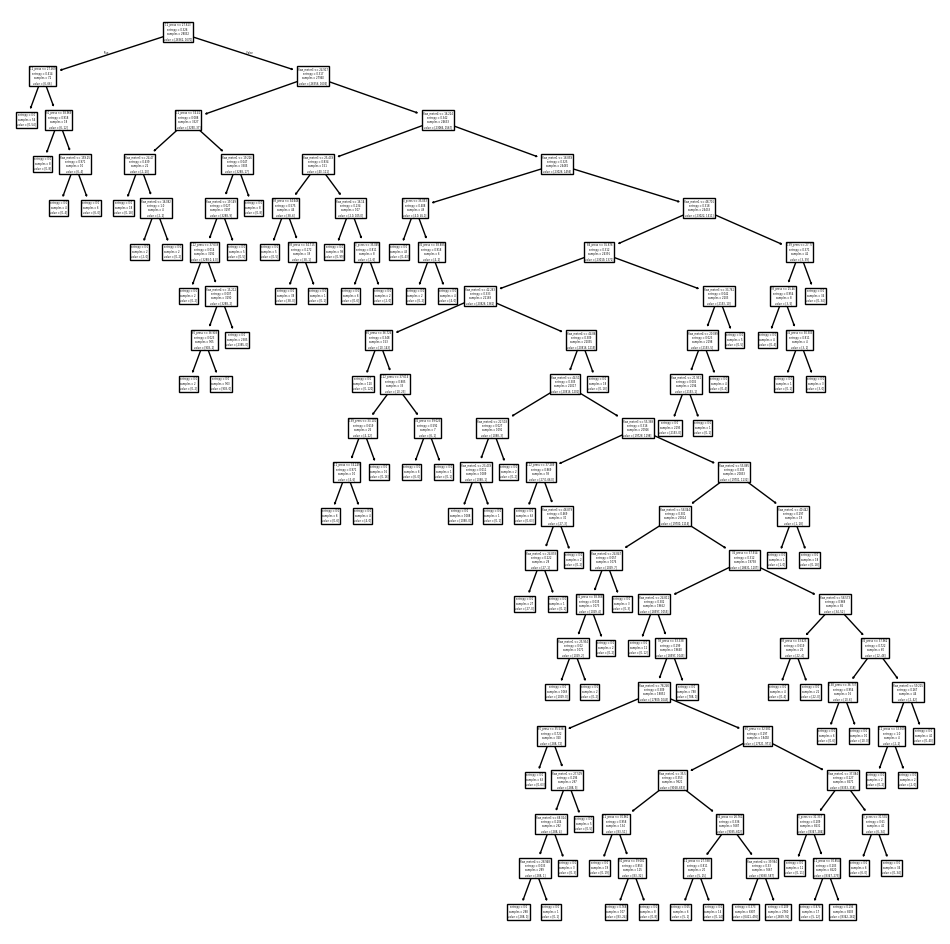

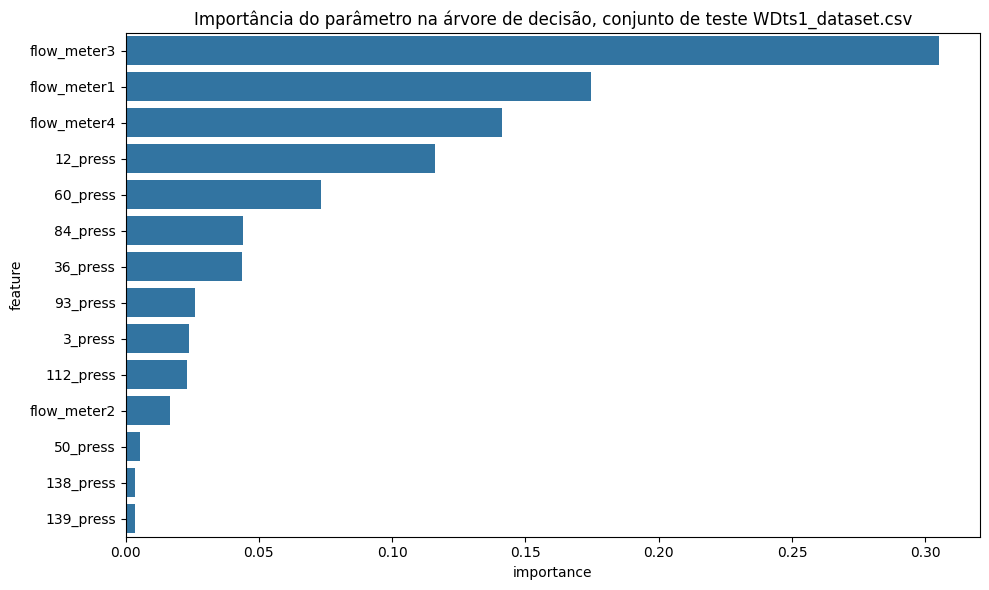


SUMÀRIO FINAL DO MODELO
Melhor critério de separação: entropy
Melhor profundidade máxima: 20
Melhor número mínimo de amostras por divisão: 2
Melhor número mínimo de amostras por folha: 1
Melhor pontuação F1 na validação cruzada: 0.6177
Pontuação ROC AUC no conjunto de teste: 0.8397
Acurácia no conjunto de teste: 0.9655
Número de parâmetros: 14
Parâmetro mais impactante: flow_meter3 (imporância: 0.3053)


In [8]:
decision_tree_pipeline(DATASETS[0])

### Conjunto WDts2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        35040 non-null  object 
 1   burst        35040 non-null  bool   
 2   flow_meter1  35040 non-null  float64
 3   flow_meter2  35040 non-null  float64
 4   flow_meter3  35040 non-null  float64
 5   flow_meter4  35040 non-null  float64
 6   3_press      35040 non-null  float64
 7   12_press     35040 non-null  float64
 8   36_press     35040 non-null  float64
 9   50_press     35040 non-null  float64
 10  60_press     35040 non-null  float64
 11  84_press     35040 non-null  float64
 12  93_press     35040 non-null  float64
 13  112_press    35040 non-null  float64
 14  138_press    35040 non-null  float64
 15  139_press    35040 non-null  float64
dtypes: bool(1), float64(14), object(1)
memory usage: 4.0+ MB
Tamanho do conjunto de treino: (28032, 14)
Tamanho do conjunto de teste: 

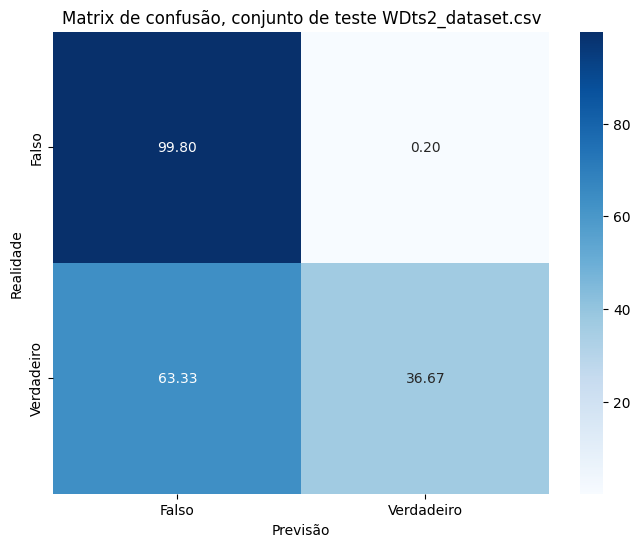

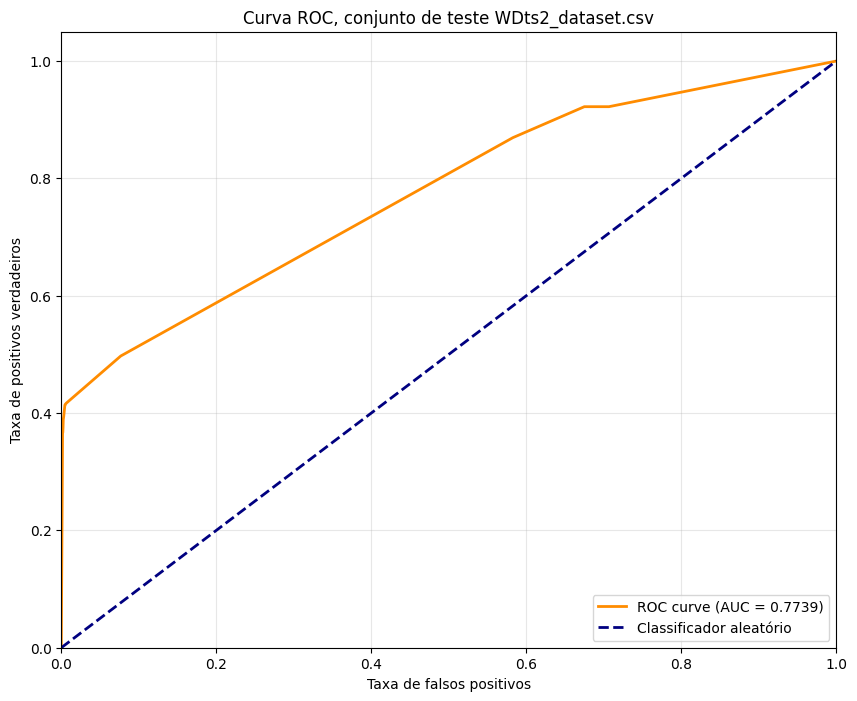

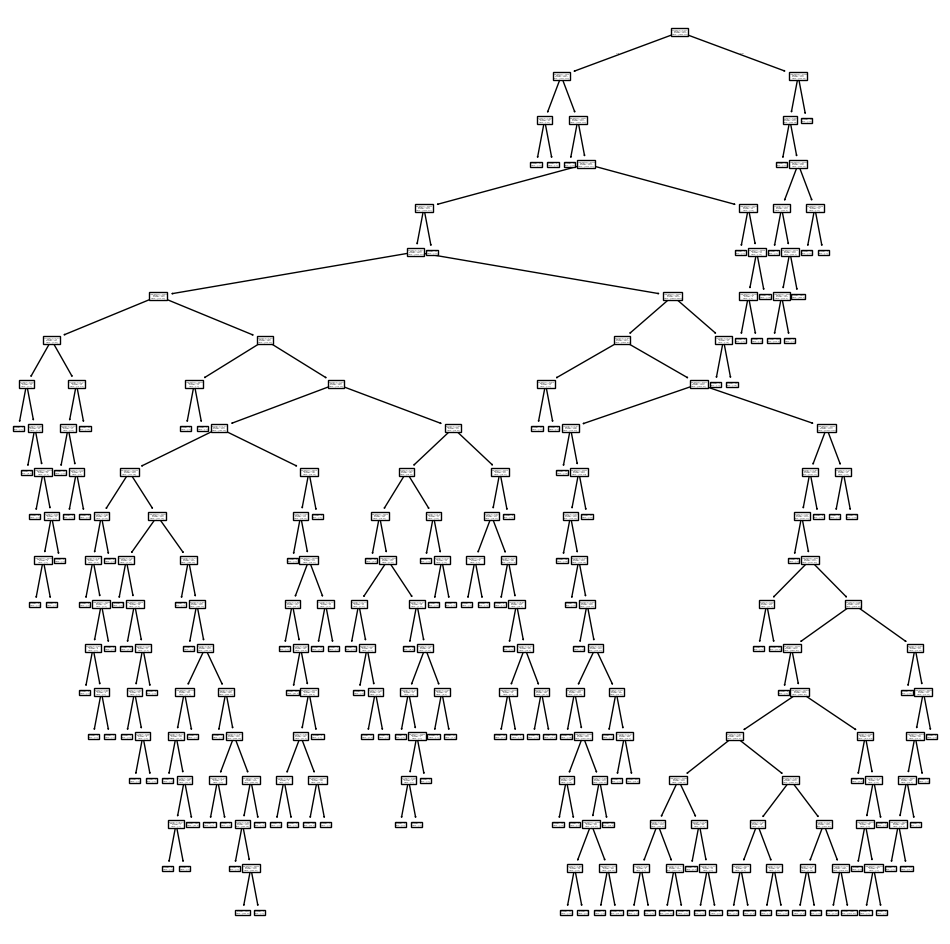

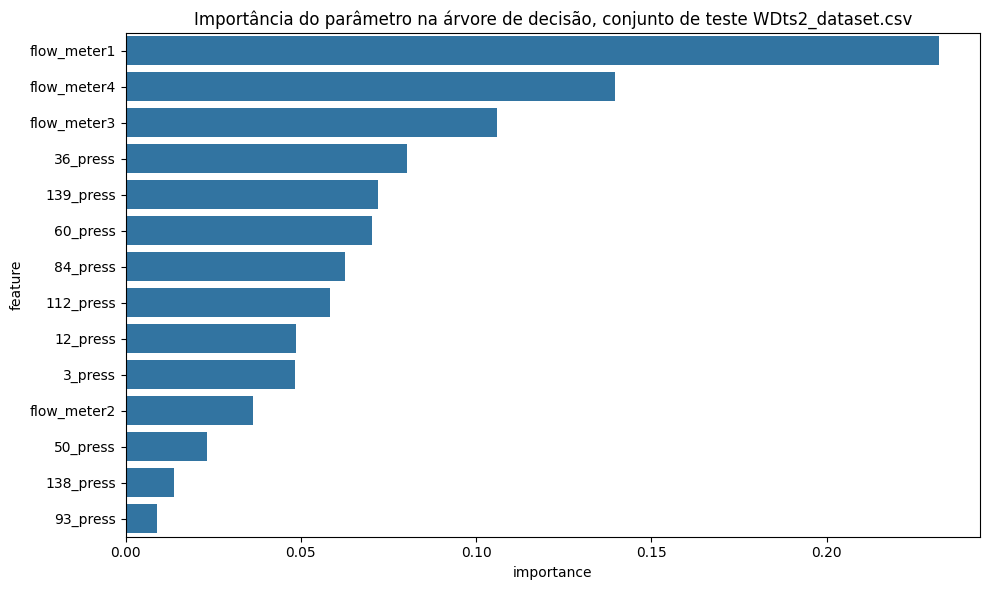


SUMÀRIO FINAL DO MODELO
Melhor critério de separação: entropy
Melhor profundidade máxima: 20
Melhor número mínimo de amostras por divisão: 5
Melhor número mínimo de amostras por folha: 1
Melhor pontuação F1 na validação cruzada: 0.5814
Pontuação ROC AUC no conjunto de teste: 0.7739
Acurácia no conjunto de teste: 0.9656
Número de parâmetros: 14
Parâmetro mais impactante: flow_meter1 (imporância: 0.2322)


In [9]:
decision_tree_pipeline(DATASETS[1])

### Conjunto WDts3

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        35040 non-null  object 
 1   burst        35040 non-null  bool   
 2   flow_meter1  35040 non-null  float64
 3   flow_meter2  35040 non-null  float64
 4   flow_meter3  35040 non-null  float64
 5   flow_meter4  35040 non-null  float64
 6   3_press      35040 non-null  float64
 7   12_press     35040 non-null  float64
 8   36_press     35040 non-null  float64
 9   50_press     35040 non-null  float64
 10  60_press     35040 non-null  float64
 11  84_press     35040 non-null  float64
 12  93_press     35040 non-null  float64
 13  112_press    35040 non-null  float64
 14  138_press    35040 non-null  float64
 15  139_press    35040 non-null  float64
dtypes: bool(1), float64(14), object(1)
memory usage: 4.0+ MB
Tamanho do conjunto de treino: (28032, 14)
Tamanho do conjunto de teste: 

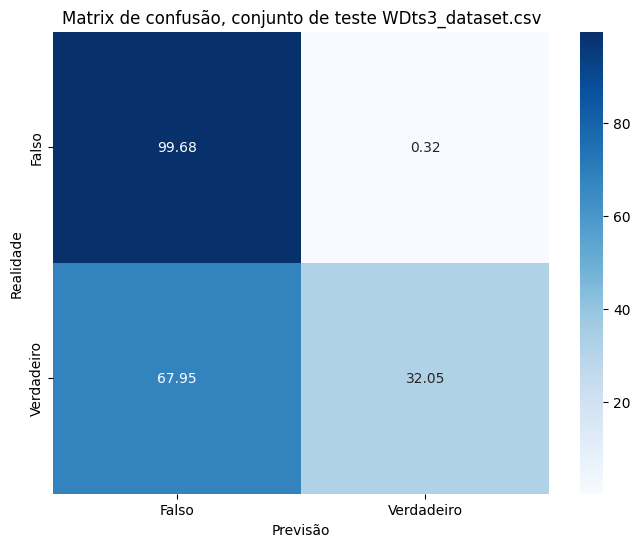

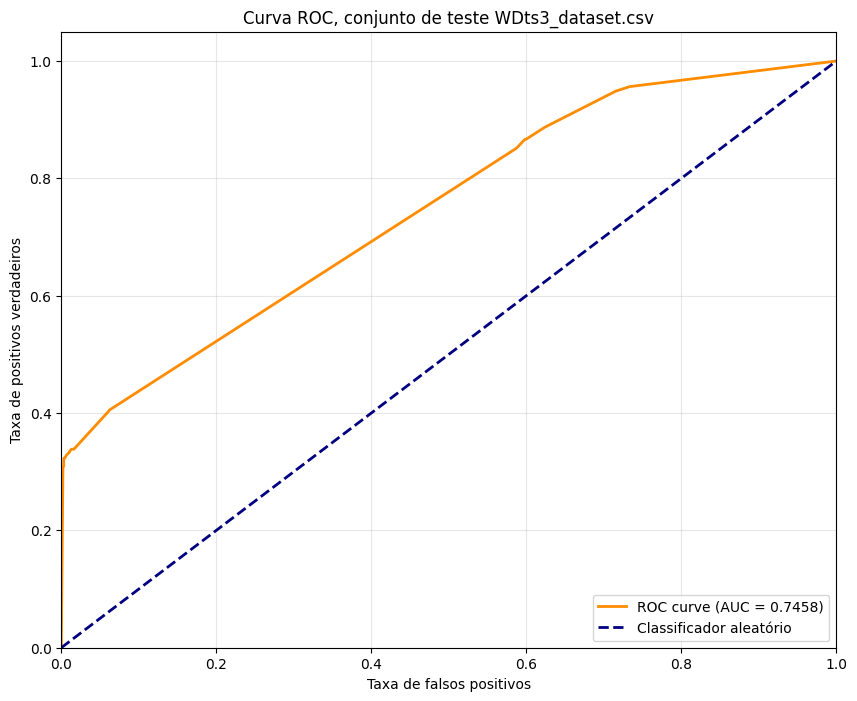

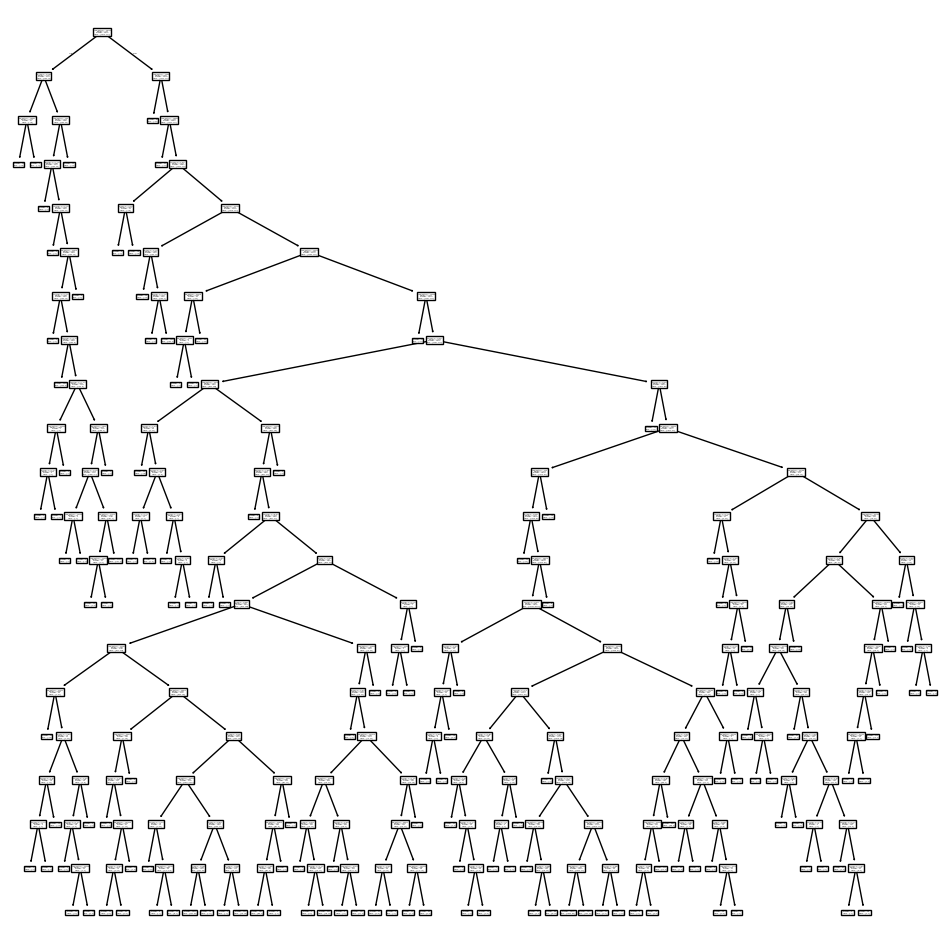

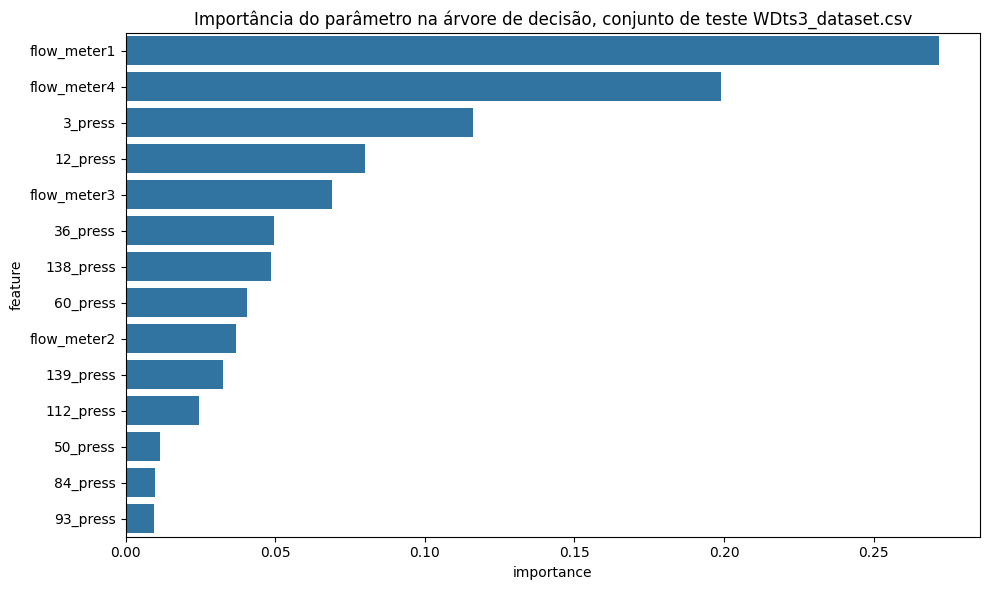


SUMÀRIO FINAL DO MODELO
Melhor critério de separação: entropy
Melhor profundidade máxima: 20
Melhor número mínimo de amostras por divisão: 2
Melhor número mínimo de amostras por folha: 1
Melhor pontuação F1 na validação cruzada: 0.4696
Pontuação ROC AUC no conjunto de teste: 0.7458
Acurácia no conjunto de teste: 0.9592
Número de parâmetros: 14
Parâmetro mais impactante: flow_meter1 (imporância: 0.2720)


In [10]:
decision_tree_pipeline(DATASETS[2])

### Conjunto WDts4

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        35040 non-null  object 
 1   burst        35040 non-null  bool   
 2   flow_meter1  35040 non-null  float64
 3   flow_meter2  35040 non-null  float64
 4   flow_meter3  35040 non-null  float64
 5   flow_meter4  35040 non-null  float64
 6   3_press      35040 non-null  float64
 7   12_press     35040 non-null  float64
 8   36_press     35040 non-null  float64
 9   50_press     35040 non-null  float64
 10  60_press     35040 non-null  float64
 11  84_press     35040 non-null  float64
 12  93_press     35040 non-null  float64
 13  112_press    35040 non-null  float64
 14  138_press    35040 non-null  float64
 15  139_press    35040 non-null  float64
dtypes: bool(1), float64(14), object(1)
memory usage: 4.0+ MB
Tamanho do conjunto de treino: (28032, 14)
Tamanho do conjunto de teste: 

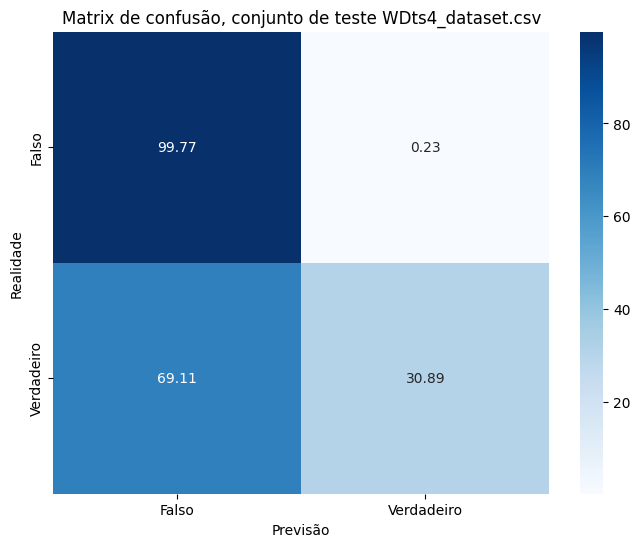

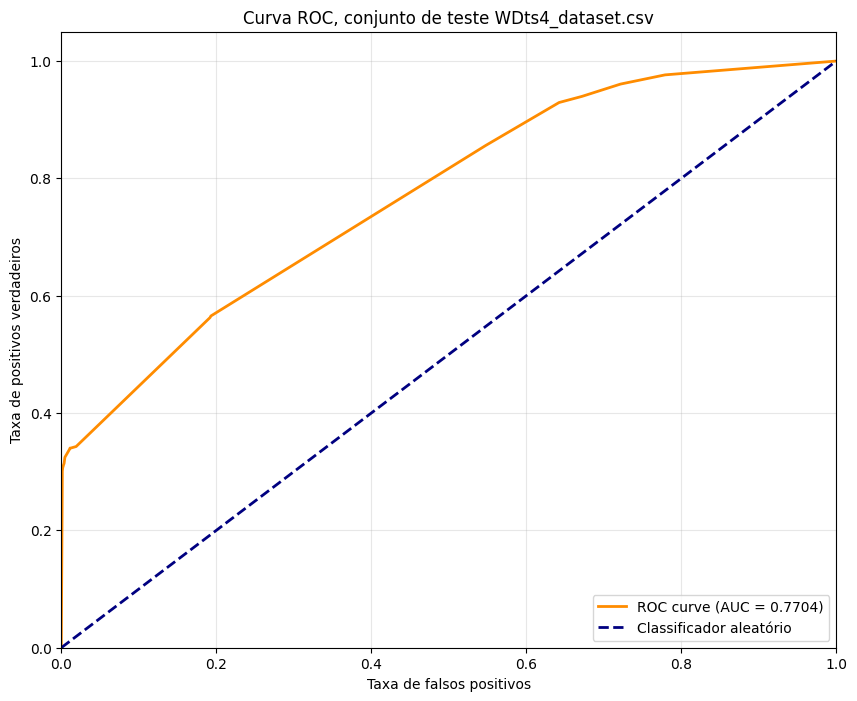

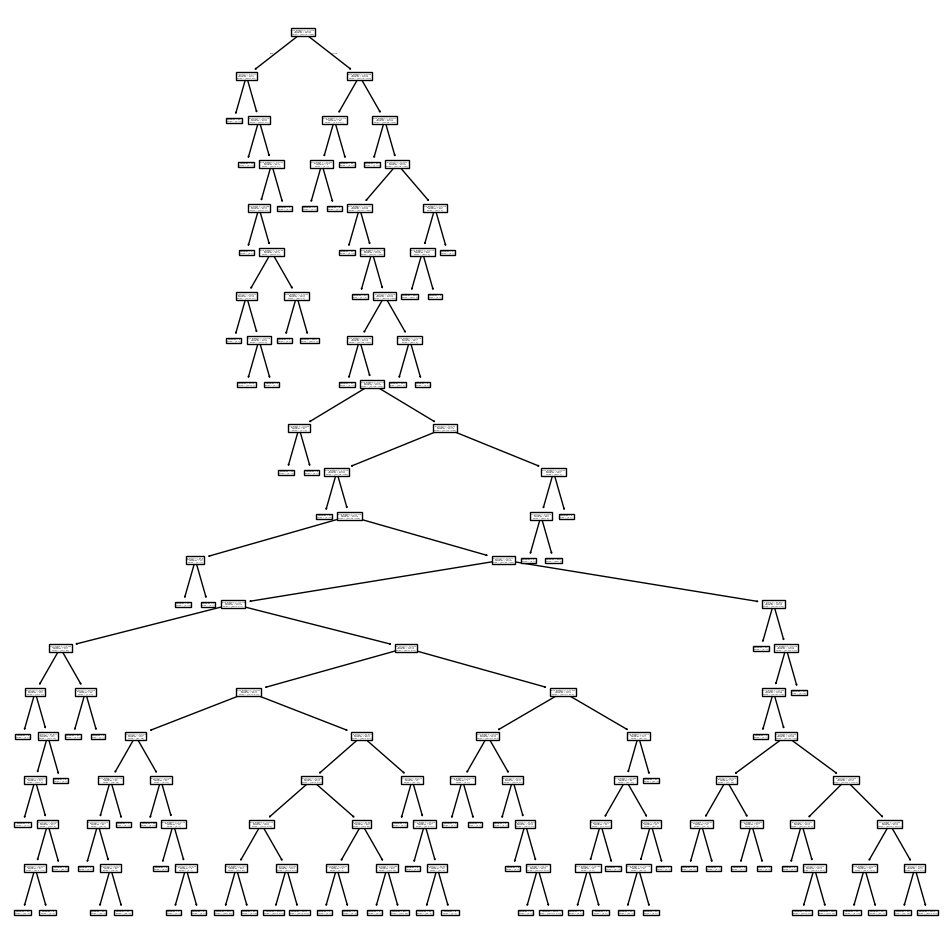

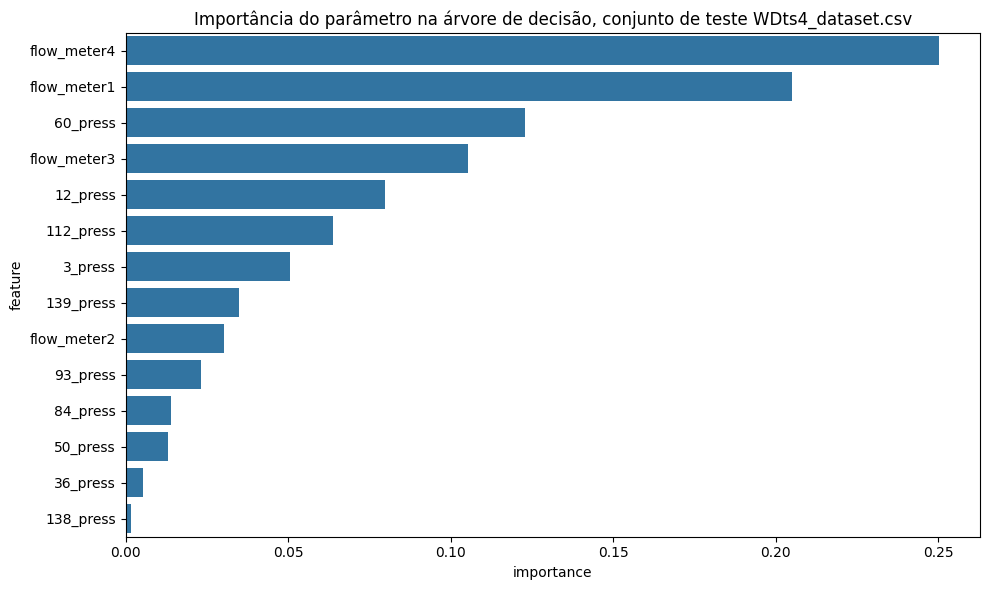


SUMÀRIO FINAL DO MODELO
Melhor critério de separação: entropy
Melhor profundidade máxima: 20
Melhor número mínimo de amostras por divisão: 5
Melhor número mínimo de amostras por folha: 1
Melhor pontuação F1 na validação cruzada: 0.4706
Pontuação ROC AUC no conjunto de teste: 0.7704
Acurácia no conjunto de teste: 0.9602
Número de parâmetros: 14
Parâmetro mais impactante: flow_meter4 (imporância: 0.2503)


In [11]:
decision_tree_pipeline(DATASETS[3])